Overall Test Accuracy: 0.9766081871345029
Train Accuracy: 0.9597989949748744
Test Accuracy: 0.9766081871345029


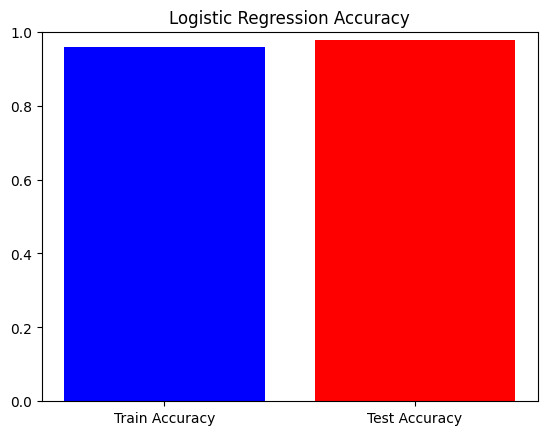

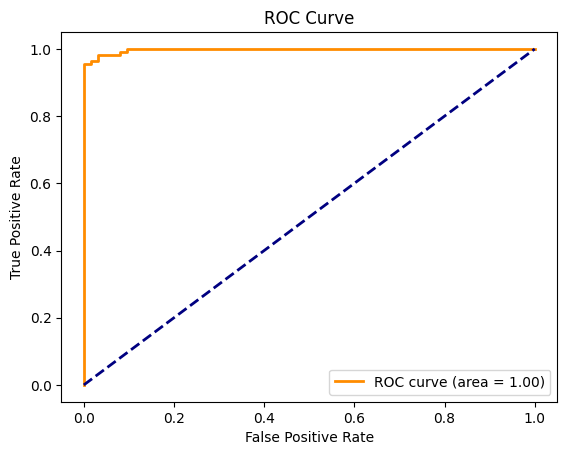

Cross-validation scores: [0.93859649 0.94736842 0.98245614 0.92982456 0.95575221]
Mean CV Accuracy: 0.9507995652848935


In [2]:
#using builtin
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split, cross_val_score

# Example dataset (replace with your own X and y)
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X, y = data.data, data.target

# Split into train/test (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train logistic regression model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# 1. Basic accuracy
print("Overall Test Accuracy:", accuracy_score(y_test, y_pred_test))

# 2. Train vs Test accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# 3. Graph of accuracy
plt.bar(["Train Accuracy", "Test Accuracy"], [train_acc, test_acc], color=["blue","red"])
plt.ylim(0,1)
plt.title("Logistic Regression Accuracy")
plt.show()

# 4. ROC Curve (TPR vs FPR)
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0,1],[0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# 5. Cross-validation
cv_scores = cross_val_score(LogisticRegression(max_iter=10000), X, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Enter number of iterations:  3



Iteration 1
        x    y    z    p  (p-y)  (p-y)*x
0     1.0  0.0  0.0  0.5    0.5      0.5
1     2.0  1.0  0.0  0.5   -0.5     -1.0
2     3.0  0.0  0.0  0.5    0.5      1.5
3     4.0  1.0  0.0  0.5   -0.5     -2.0
Sum  10.0  2.0  0.0  2.0    0.0     -1.0
Gradient wrt m: -1.0
Gradient wrt c: 0.0
Updated slope (m): -0.1
Updated intercept (c): 0.0
Iteration Accuracy: 0.5

Iteration 2
        x    y    z         p     (p-y)   (p-y)*x
0     1.0  0.0 -0.1  0.475021  0.475021  0.475021
1     2.0  1.0 -0.2  0.450166 -0.549834 -1.099668
2     3.0  0.0 -0.3  0.425557  0.425557  1.276672
3     4.0  1.0 -0.4  0.401312 -0.598688 -2.394751
Sum  10.0  2.0 -1.0  1.752057 -0.247943 -1.742725
Gradient wrt m: -1.7427253729886807
Gradient wrt c: -0.24794336171552883
Updated slope (m): -0.2742725372988681
Updated intercept (c): -0.024794336171552883
Iteration Accuracy: 0.5

Iteration 3
        x    y         z         p     (p-y)   (p-y)*x
0     1.0  0.0 -0.299067  0.425786  0.425786  0.425786
1     2.

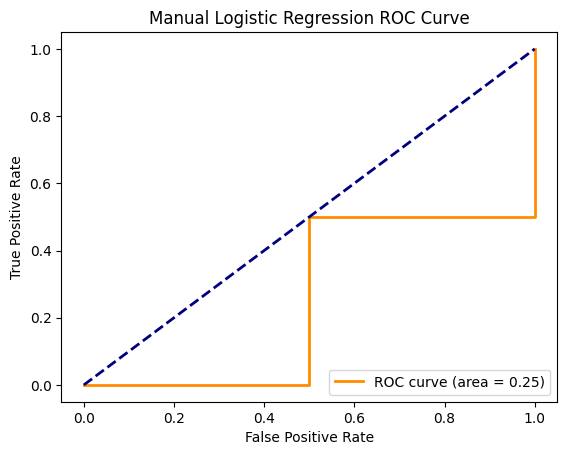

In [5]:
#without builtin
import numpy as np
import pandas as pd

# User inputs
X = np.array([1,2,3,4])   # features
y = np.array([0,1,0,1])   # labels
iterations = int(input("Enter number of iterations: "))
alpha = 0.1  # learning rate

# Initialize weights
m, c = 0.0, 0.0

for it in range(1, iterations+1):
    # Linear part
    z = m*X + c
    
    # Sigmoid probability
    p = 1 / (1 + np.exp(-z))
    
    # Loss terms
    loss = p - y
    grad_m = loss * X
    grad_c = loss
    
    # Build table
    df = pd.DataFrame({
        "x": X,
        "y": y,
        "z": z,
        "p": p,
        "(p-y)": loss,
        "(p-y)*x": grad_m
    })
    
    # Add summation row
    df.loc["Sum"] = df.sum()
    
    print(f"\nIteration {it}")
    print(df)
    
    # Gradients
    dL_dm = df.loc["Sum","(p-y)*x"]
    dL_dc = df.loc["Sum","(p-y)"]
    
    print("Gradient wrt m:", dL_dm)
    print("Gradient wrt c:", dL_dc)
    
    # Weight update
    m = m + alpha * dL_dm
    c = c + alpha * dL_dc
    
    print("Updated slope (m):", m)
    print("Updated intercept (c):", c)
    # --- NEW: Accuracy ---
    y_pred_class = (p >= 0.5).astype(int)   # threshold at 0.5
    acc = accuracy_score(y, y_pred_class)
    print("Iteration Accuracy:", acc)

# --- After all iterations: ROC Curve ---
z_final = m*X + c
p_final = 1 / (1 + np.exp(-z_final))

fpr, tpr, thresholds = roc_curve(y, p_final)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0,1],[0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Manual Logistic Regression ROC Curve")
plt.legend(loc="lower right")
plt.show()


In [12]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Define splits and test sizes
splits = {"60-40":0.4, "70-30":0.3, "80-20":0.2}
test_sizes = [0.1, 0.2, 0.3]  # representing 10, 20, 30

# Define models
models = {
    "Basic LR": LogisticRegression(penalty=None, solver="lbfgs", max_iter=20000),
    "LR with L1": LogisticRegression(penalty="l1", solver="saga", max_iter=20000),
    "LR with L2": LogisticRegression(penalty="l2", solver="lbfgs", max_iter=20000)
}

rows = []
index = []
for model_name, model in models.items():
    for split_name, split_val in splits.items():
        accs, precs, recs, f1s, mean_accs = [], [], [], [], []
        for ts in test_sizes:
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ts, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            accs.append(accuracy_score(y_test, y_pred))
            precs.append(precision_score(y_test, y_pred))
            recs.append(recall_score(y_test, y_pred))
            f1s.append(f1_score(y_test, y_pred))
            mean_accs.append(np.mean(accs))  # mean accuracy up to this point
        
        rows.append(accs + precs + recs + f1s + mean_accs)
        index.append((model_name, split_name))

# MultiIndex columns: metrics × subcolumns
metrics = ["Accuracy","Precision","Recall","F1-Score","Mean Accuracy"]
subcols = ["10","20","30"]
arrays = (
    [m for m in metrics for _ in subcols],
    subcols*len(metrics)
)
columns = pd.MultiIndex.from_arrays(arrays)

# Build DataFrame
df = pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(index, names=["Model","Split"]), columns=columns)

# Display table
print(df)


                  Accuracy                     Precision                      \
                        10        20        30        10        20        30   
Model      Split                                                               
Basic LR   60-40  0.912281  0.938596  0.959064  0.972973  0.970588  0.990291   
           70-30  0.912281  0.938596  0.959064  0.972973  0.970588  0.990291   
           80-20  0.912281  0.938596  0.959064  0.972973  0.970588  0.990291   
LR with L1 60-40  0.964912  0.964912  0.982456  0.975000  0.971831  0.990654   
           70-30  0.964912  0.964912  0.982456  0.975000  0.971831  0.990654   
           80-20  0.964912  0.964912  0.982456  0.975000  0.971831  0.990654   
LR with L2 60-40  0.982456  0.973684  0.982456  0.975610  0.972222  0.990654   
           70-30  0.982456  0.973684  0.982456  0.975610  0.972222  0.990654   
           80-20  0.982456  0.973684  0.982456  0.975610  0.972222  0.990654   

                 Recall                